# Notebook 06 — Modelagem Preditiva
**Desempenho Socioeconômico no ENEM (2012–2024)**

Este notebook cobre a **Etapa 3: Resultados Parciais** do projeto.

### Objetivos
- Treinar modelos KNN para prever a faixa de nota do candidato (FAIXA_MT e FAIXA_REDACAO)
- Comparar 2 configurações de features: ENEM-only vs ENEM+IDHM
- Avaliar se os indicadores socioeconômicos estaduais agregam poder preditivo ao modelo

### Estrutura
| Seção | Conteúdo |
|---|---|
| 0 | Setup e configuração |
| 1 | Carregamento via DuckDB (500k amostras, 3 classes) |
| 2 | Pré-processamento (encoding) |
| 3 | Split 60/20/20 |
| 4 | Baseline (DummyClassifier) |
| 5 | Modelo 1: KNN — ENEM only |
| 6 | Modelo 2: KNN — ENEM + IDHM |
| 7 | Comparação e figuras para o artigo |
| 8 | FAIXA_REDACAO (segundo target) |
| 9 | Persistência dos modelos |
| 10 | Discussão preliminar e limitações |

## Seção 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
N_SAMPLE     = 500_000
K_GRID       = [5, 7, 9, 11, 21]
METRICS      = ['euclidean', 'manhattan']

DATA_DIR   = '../data/processed'
MODELS_DIR = '../data/models'
FIGS_DIR   = DATA_DIR

os.makedirs(MODELS_DIR, exist_ok=True)

# 3 classes: Baixo (<500) | Médio (500-700) | Alto (>700)
FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# Mapeamento das faixas originais → 3 classes
FAIXA_3_MAP = {
    '<400'    : 0, '400-500': 0,   # Baixo
    '500-600' : 1, '600-700': 1,   # Médio
    '700-800' : 2, '>800'   : 2,   # Alto
}

print('Configuração OK')
print(f'  N_SAMPLE = {N_SAMPLE:,}')
print(f'  K_GRID   = {K_GRID}')
print(f'  METRICS  = {METRICS}')
print(f'  Classes  : {FAIXA_ORDER}')

Configuração OK
  N_SAMPLE = 500,000
  K_GRID   = [5, 7, 9, 11, 21]
  METRICS  = ['euclidean', 'manhattan']
  Classes  : ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']


## Seção 1 — Carregamento via DuckDB

DuckDB lê o parquet, filtra os registros com IDHM, mapeia as 6 faixas originais para 3 classes
e retira uma amostra de 500k — tudo antes de tocar no pandas.
Assim a RAM nunca carrega mais de 500k linhas.

In [2]:
import duckdb

PARQUET = f'{DATA_DIR}/dataset_analitico.parquet'

con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        FAIXA_MT, FAIXA_REDACAO,
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        CASE
            WHEN FAIXA_MT IN ('<400', '400-500')   THEN 0
            WHEN FAIXA_MT IN ('500-600', '600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800', '>800')    THEN 2
        END::TINYINT AS y_mt,
        CASE
            WHEN FAIXA_REDACAO IN ('<400', '400-500')   THEN 0
            WHEN FAIXA_REDACAO IN ('500-600', '600-700') THEN 1
            WHEN FAIXA_REDACAO IN ('700-800', '>800')    THEN 2
        END::TINYINT AS y_red
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra carregada: {len(df):,} registros')
print('\nDistribuição das 3 classes (y_mt):')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra carregada: 139,027 registros

Distribuição das 3 classes (y_mt):
  Baixo (<500): 72,719 (52.3%)
  Médio (500–700): 56,457 (40.6%)
  Alto (>700): 9,851 (7.1%)


## Seção 2 — Pré-processamento

Encoding das variáveis categóricas em cima dos 500k registros já carregados.
O pipeline sklearn (imputer + scaler) será ajustado **apenas no treino** para evitar data leakage.

In [3]:
SEXO_MAP   = {'F': 0, '0': 0, 'M': 1, '1': 1}
LETTER_MAP = {c: i for i, c in enumerate('ABCDEFGHI')}
INCOME_MAP = {c: i for i, c in enumerate('ABCDE')}
REGIAO_MAP = {'Norte': 0, 'Nordeste': 1, 'Centro-Oeste': 2, 'Sul': 3, 'Sudeste': 4}

df['tp_sexo']   = df['TP_SEXO'].map(SEXO_MAP)
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'], errors='coerce')
df['q001']      = df['Q001'].map(LETTER_MAP)
df['q002']      = df['Q002'].map(LETTER_MAP)
df['q006']      = df['Q006_HARM'].map(INCOME_MAP)
df['regiao']    = df['REGIAO'].map(REGIAO_MAP)
df['ano']       = df['NU_ANO'].astype('float32')

# Encoding das questões socioeconômicas estendidas (Q_*)
def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

FEATS_BASE = ['tp_sexo', 'tp_cor', 'tp_escola', 'q001', 'q002', 'q006', 'regiao', 'ano']
FEATS_IDHM = [
    'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_longevidade',
    'renda_percapita', 'tx_analfabetismo', 'tx_envelhecimento',
    'esperanca_vida', 'mortalidade_infantil'
]
FEATS_Q_EXT = [
    'q_ocup_pai', 'q_ocup_mae', 'q_n_pessoas', 'q_empregada',
    'q_carro', 'q_moto', 'q_geladeira', 'q_lavadora', 'q_tv',
    'q_computador', 'q_internet', 'q_celular', 'q_tipo_esc_em', 'q_bolsa_fam'
]

FEATS_M1 = FEATS_BASE                          # ENEM only (8 features)
FEATS_M2 = FEATS_BASE + FEATS_IDHM             # ENEM + IDHM estadual (17 features)
FEATS_M3 = FEATS_BASE + FEATS_Q_EXT            # ENEM + Qs estendidas (22 features)
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_Q_EXT  # tudo (31 features)

print(f'M1: {len(FEATS_M1)} features | M2: {len(FEATS_M2)} | M3: {len(FEATS_M3)} | M4: {len(FEATS_M4)}')
print('Pré-processamento OK')


M1: 8 features | M2: 17 | M3: 22 | M4: 31
Pré-processamento OK


## Seção 3 — Split 60/20/20

Amostragem já foi feita pelo DuckDB. Aqui apenas dividimos os 500k em treino/validação/teste.

In [4]:
# ALL_FEATS = M4 (superset); M1/M2/M3 são slices por índice
ALL_FEATS = FEATS_M4

X_all = df[ALL_FEATS].values.astype('float32')
y_mt  = df['y_mt'].values.astype('int8')

# Índices de cada conjunto de features dentro de ALL_FEATS
idx_m1 = list(range(len(FEATS_M1)))             # base: 8 features
idx_m2 = list(range(len(FEATS_M2)))             # base + IDHM: 17 features
idx_m3 = (list(range(len(FEATS_BASE))) +         # base + Q_EXT: 22 features
          list(range(len(FEATS_M2), len(FEATS_M4))))
idx_m4 = list(range(len(FEATS_M4)))             # tudo: 31 features

# Split 60/20/20 estratificado
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_mt, test_size=0.20, stratify=y_mt, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE
)

# Slices por modelo
Xtr_m1, Xv_m1, Xte_m1 = X_train[:, idx_m1], X_val[:, idx_m1], X_test[:, idx_m1]
Xtr_m2, Xv_m2, Xte_m2 = X_train[:, idx_m2], X_val[:, idx_m2], X_test[:, idx_m2]
Xtr_m3, Xv_m3, Xte_m3 = X_train[:, idx_m3], X_val[:, idx_m3], X_test[:, idx_m3]
Xtr_m4, Xv_m4, Xte_m4 = X_train[:, idx_m4], X_val[:, idx_m4], X_test[:, idx_m4]

print('Split 60/20/20:')
print(f'  Treino     : {len(y_train):,} ({len(y_train)/len(y_mt)*100:.0f}%)')
print(f'  Validação  : {len(y_val):,} ({len(y_val)/len(y_mt)*100:.0f}%)')
print(f'  Teste      : {len(y_test):,} ({len(y_test)/len(y_mt)*100:.0f}%) [SELADO]')
print(f'\nFeatures: M1={len(idx_m1)} | M2={len(idx_m2)} | M3={len(idx_m3)} | M4={len(idx_m4)}')
print('\nClasses no treino:')
for code in sorted(np.unique(y_train)):
    n = (y_train == code).sum()
    print(f'  {FAIXA_MAP_INV[code]}: {n:,} ({n/len(y_train)*100:.1f}%)')


Split 60/20/20:
  Treino     : 83,415 (60%)
  Validação  : 27,806 (20%)
  Teste      : 27,806 (20%) [SELADO]

Features: M1=8 | M2=17 | M3=22 | M4=31

Classes no treino:
  Baixo (<500): 43,631 (52.3%)
  Médio (500–700): 33,873 (40.6%)
  Alto (>700): 5,911 (7.1%)


## Seção 5 — Baseline: DummyClassifier

Baseline trivial: sempre prediz a classe mais frequente (`400-500`, ~36% dos casos).
Qualquer modelo com valor preditivo real deve superar este baseline.

In [5]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(Xtr_m1, y_train)
y_dummy = dummy.predict(Xv_m1)

baseline_metrics = {
    'Accuracy'    : accuracy_score(y_val, y_dummy),
    'Macro F1'    : f1_score(y_val, y_dummy, average='macro'),
    'Weighted F1' : f1_score(y_val, y_dummy, average='weighted'),
}

print('Baseline (majority class):')
for k, v in baseline_metrics.items():
    print(f'  {k:<15s}: {v:.4f}')

Baseline (majority class):
  Accuracy       : 0.5231
  Macro F1       : 0.2289
  Weighted F1    : 0.3593


## Seção 6 — Modelo 1: KNN (ENEM only)

Features: variáveis individuais e do questionário socioeconômico do ENEM.  
Seleção de k por **Macro F1 no validation set** (mais justo com classes desbalanceadas).

O pipeline sklearn garante que imputação e normalização são ajustadas **só no treino**.

In [6]:
def make_knn_pipeline(k, metric='euclidean'):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('knn',     KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=1, algorithm='auto'))
    ])

def select_best_params(X_tr, X_v, y_tr, y_v, label=''):
    """Busca grid (k x metric) no val set. Retorna dict com todos resultados e melhor combo."""
    print(f'{"k":>4s}  {"metric":>12s}  {"Accuracy":>9s}  {"Macro F1":>9s}  {"Weighted F1":>11s}')
    print('-' * 55)
    results = {}
    for metric in METRICS:
        for k in K_GRID:
            pipe = make_knn_pipeline(k, metric)
            pipe.fit(X_tr, y_tr)
            yp = pipe.predict(X_v)
            results[(k, metric)] = {
                'acc':         accuracy_score(y_v, yp),
                'f1_macro':    f1_score(y_v, yp, average='macro'),
                'f1_weighted': f1_score(y_v, yp, average='weighted'),
            }
            r = results[(k, metric)]
            print(f'{k:>4d}  {metric:>12s}  {r["acc"]:>9.4f}  {r["f1_macro"]:>9.4f}  {r["f1_weighted"]:>11.4f}')
    best = max(results, key=lambda p: results[p]['f1_macro'])
    print(f'\n  Melhor combo (Macro F1): k={best[0]}, metric={best[1]}  →  F1={results[best]["f1_macro"]:.4f}')
    return results, best

print('=== Modelo 1: KNN (ENEM only) — Grid k × métrica ===')
k_results_m1, best_params_m1 = select_best_params(Xtr_m1, Xv_m1, y_train, y_val)

=== Modelo 1: KNN (ENEM only) — Grid k × métrica ===
   k        metric   Accuracy   Macro F1  Weighted F1
-------------------------------------------------------
   5     euclidean     0.5717     0.4631       0.5607
   7     euclidean     0.5806     0.4744       0.5697
   9     euclidean     0.5852     0.4713       0.5726
  11     euclidean     0.5913     0.4719       0.5780
  21     euclidean     0.6027     0.4795       0.5876
   5     manhattan     0.5725     0.4626       0.5612
   7     manhattan     0.5825     0.4754       0.5714
   9     manhattan     0.5876     0.4764       0.5750
  11     manhattan     0.5928     0.4743       0.5795
  21     manhattan     0.6042     0.4810       0.5884

  Melhor combo (Macro F1): k=21, metric=manhattan  →  F1=0.4810


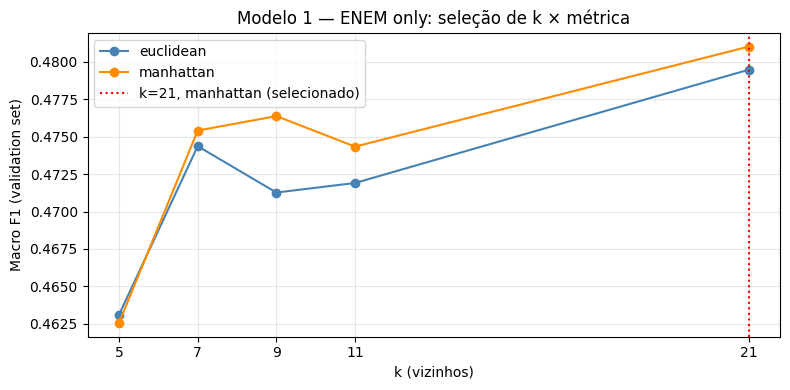

Figura salva: fig_kselect_m1.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = {'euclidean': 'steelblue', 'manhattan': 'darkorange'}
for metric in METRICS:
    ks   = K_GRID
    f1s  = [k_results_m1[(k, metric)]['f1_macro'] for k in ks]
    ax.plot(ks, f1s, 'o-', color=colors[metric], label=metric)

best_k_m1, best_metric_m1 = best_params_m1
ax.axvline(best_k_m1, color='red', linestyle=':', linewidth=1.5,
           label=f'k={best_k_m1}, {best_metric_m1} (selecionado)')
ax.set_xlabel('k (vizinhos)')
ax.set_ylabel('Macro F1 (validation set)')
ax.set_title('Modelo 1 — ENEM only: seleção de k × métrica')
ax.set_xticks(K_GRID)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_kselect_m1.png', dpi=150)
plt.show()
print('Figura salva: fig_kselect_m1.png')

In [8]:
best_k_m1, best_metric_m1 = best_params_m1
print(f'=== Modelo 1 — treino final: k={best_k_m1}, metric={best_metric_m1} ===')

pipe_m1 = make_knn_pipeline(best_k_m1, best_metric_m1)
pipe_m1.fit(Xtr_m1, y_train)
yp_m1 = pipe_m1.predict(Xv_m1)

m1_metrics = {
    'Accuracy'    : accuracy_score(y_val, yp_m1),
    'Macro F1'    : f1_score(y_val, yp_m1, average='macro'),
    'Weighted F1' : f1_score(y_val, yp_m1, average='weighted'),
}

print('\nMétricas no validation set:')
for metric, val in m1_metrics.items():
    print(f'  {metric:<15s}: {val:.4f}')

print('\nClassification Report:')
target_names = [FAIXA_MAP_INV[i] for i in sorted(np.unique(y_val))]
print(classification_report(y_val, yp_m1, target_names=target_names))

=== Modelo 1 — treino final: k=21, metric=manhattan ===

Métricas no validation set:
  Accuracy       : 0.6042
  Macro F1       : 0.4810
  Weighted F1    : 0.5884

Classification Report:
                 precision    recall  f1-score   support

   Baixo (<500)       0.65      0.77      0.71     14544
Médio (500–700)       0.53      0.47      0.50     11292
    Alto (>700)       0.46      0.16      0.24      1970

       accuracy                           0.60     27806
      macro avg       0.55      0.47      0.48     27806
   weighted avg       0.59      0.60      0.59     27806



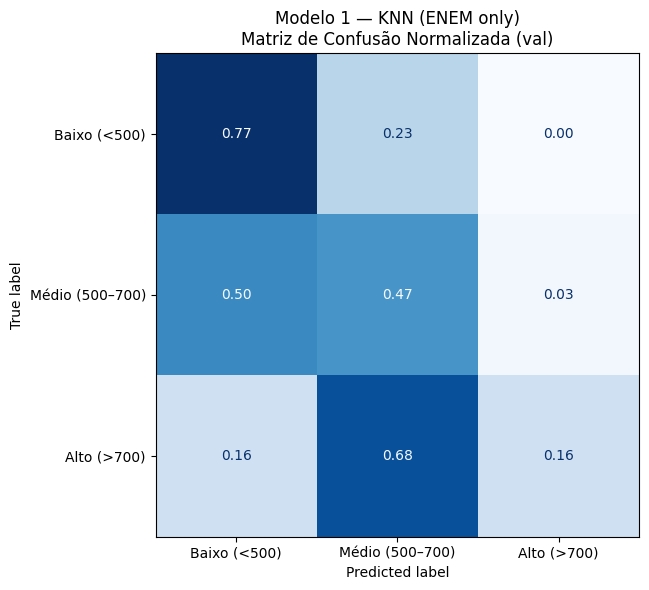

Figura salva: fig_cm_m1.png


In [9]:
cm_m1 = confusion_matrix(y_val, yp_m1, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm_m1, display_labels=FAIXA_ORDER)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
ax.set_title('Modelo 1 — KNN (ENEM only)\nMatriz de Confusão Normalizada (val)')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_cm_m1.png', dpi=150)
plt.show()
print('Figura salva: fig_cm_m1.png')

## Seção 7 — Modelo 2: KNN (ENEM + IDHM)

Adiciona 9 indicadores socioeconômicos estaduais do Atlas Brasil ao conjunto de features.

**Hipótese testada (H3):** O IDHM estadual explica variância adicional além das variáveis 
individuais do questionário ENEM.

In [10]:
print('=== Modelo 2: KNN (ENEM + IDHM) — Grid k × métrica ===')
k_results_m2, best_params_m2 = select_best_params(Xtr_m2, Xv_m2, y_train, y_val)

=== Modelo 2: KNN (ENEM + IDHM) — Grid k × métrica ===
   k        metric   Accuracy   Macro F1  Weighted F1
-------------------------------------------------------
   5     euclidean     0.5753     0.4606       0.5630
   7     euclidean     0.5809     0.4639       0.5681
   9     euclidean     0.5818     0.4627       0.5684
  11     euclidean     0.5893     0.4662       0.5749
  21     euclidean     0.6001     0.4608       0.5821
   5     manhattan     0.5760     0.4601       0.5632
   7     manhattan     0.5854     0.4660       0.5721
   9     manhattan     0.5896     0.4638       0.5753
  11     manhattan     0.5897     0.4601       0.5742
  21     manhattan     0.6017     0.4588       0.5837

  Melhor combo (Macro F1): k=11, metric=euclidean  →  F1=0.4662


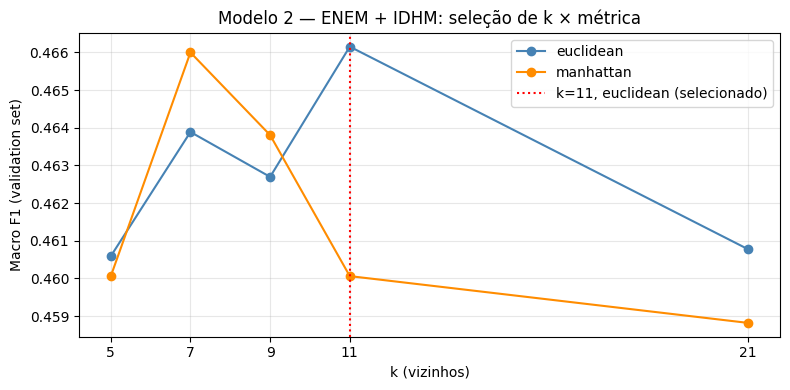

Figura salva: fig_kselect_m2.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for metric in METRICS:
    f1s = [k_results_m2[(k, metric)]['f1_macro'] for k in K_GRID]
    ax.plot(K_GRID, f1s, 'o-', color=colors[metric], label=metric)

best_k_m2, best_metric_m2 = best_params_m2
ax.axvline(best_k_m2, color='red', linestyle=':', linewidth=1.5,
           label=f'k={best_k_m2}, {best_metric_m2} (selecionado)')
ax.set_xlabel('k (vizinhos)')
ax.set_ylabel('Macro F1 (validation set)')
ax.set_title('Modelo 2 — ENEM + IDHM: seleção de k × métrica')
ax.set_xticks(K_GRID)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_kselect_m2.png', dpi=150)
plt.show()
print('Figura salva: fig_kselect_m2.png')

In [12]:
best_k_m2, best_metric_m2 = best_params_m2
print(f'=== Modelo 2 — treino final: k={best_k_m2}, metric={best_metric_m2} ===')

pipe_m2 = make_knn_pipeline(best_k_m2, best_metric_m2)
pipe_m2.fit(Xtr_m2, y_train)
yp_m2 = pipe_m2.predict(Xv_m2)

m2_metrics = {
    'Accuracy'    : accuracy_score(y_val, yp_m2),
    'Macro F1'    : f1_score(y_val, yp_m2, average='macro'),
    'Weighted F1' : f1_score(y_val, yp_m2, average='weighted'),
}

print('\nMétricas no validation set:')
for metric, val in m2_metrics.items():
    print(f'  {metric:<15s}: {val:.4f}')

print('\nClassification Report:')
print(classification_report(y_val, yp_m2, target_names=target_names))

=== Modelo 2 — treino final: k=11, metric=euclidean ===

Métricas no validation set:
  Accuracy       : 0.5893
  Macro F1       : 0.4662
  Weighted F1    : 0.5749

Classification Report:
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.74      0.69     14544
Médio (500–700)       0.52      0.47      0.49     11292
    Alto (>700)       0.42      0.15      0.22      1970

       accuracy                           0.59     27806
      macro avg       0.53      0.45      0.47     27806
   weighted avg       0.57      0.59      0.57     27806



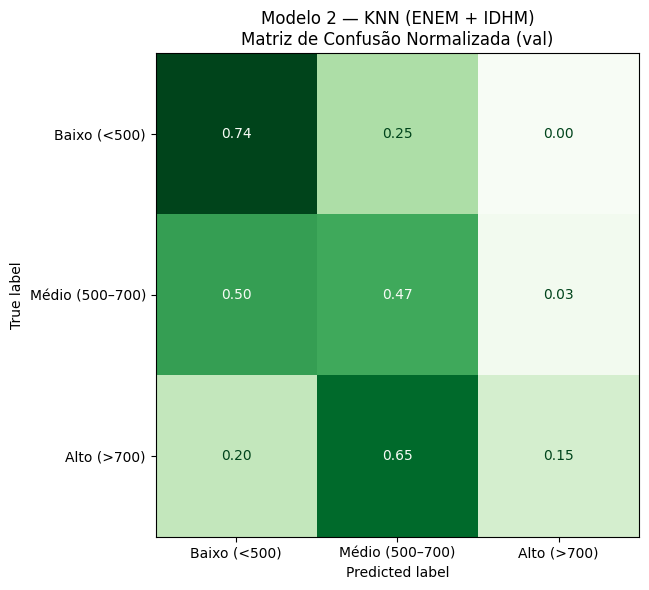

Figura salva: fig_cm_m2.png


In [13]:
cm_m2 = confusion_matrix(y_val, yp_m2, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm_m2, display_labels=FAIXA_ORDER)
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='.2f')
ax.set_title('Modelo 2 — KNN (ENEM + IDHM)\nMatriz de Confusão Normalizada (val)')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_cm_m2.png', dpi=150)
plt.show()
print('Figura salva: fig_cm_m2.png')

## Seção 8 — Comparação e Figuras para o Artigo

In [14]:
rows = [
    ('Baseline (majority)', '—', '—', baseline_metrics['Accuracy'],
     baseline_metrics['Macro F1'], baseline_metrics['Weighted F1']),
    ('KNN — ENEM only', best_k_m1, best_metric_m1,
     m1_metrics['Accuracy'], m1_metrics['Macro F1'], m1_metrics['Weighted F1']),
    ('KNN — ENEM + IDHM', best_k_m2, best_metric_m2,
     m2_metrics['Accuracy'], m2_metrics['Macro F1'], m2_metrics['Weighted F1']),
]

df_results = pd.DataFrame(rows,
    columns=['Modelo', 'k', 'Métrica dist.', 'Accuracy', 'Macro F1', 'Weighted F1'])

print('=== Tabela Comparativa — FAIXA_MT (validation set) ===')
print(df_results.to_string(index=False))

delta_acc = m2_metrics['Accuracy'] - m1_metrics['Accuracy']
delta_f1  = m2_metrics['Macro F1'] - m1_metrics['Macro F1']
print(f'\nGanho Modelo 2 vs Modelo 1:')
print(f'  Δ Accuracy = {delta_acc:+.4f}')
print(f'  Δ Macro F1 = {delta_f1:+.4f}')

=== Tabela Comparativa — FAIXA_MT (validation set) ===
             Modelo  k Métrica dist.  Accuracy  Macro F1  Weighted F1
Baseline (majority)  —             —  0.523053  0.228949     0.359257
    KNN — ENEM only 21     manhattan  0.604186  0.481009     0.588399
  KNN — ENEM + IDHM 11     euclidean  0.589333  0.466152     0.574934

Ganho Modelo 2 vs Modelo 1:
  Δ Accuracy = -0.0149
  Δ Macro F1 = -0.0149


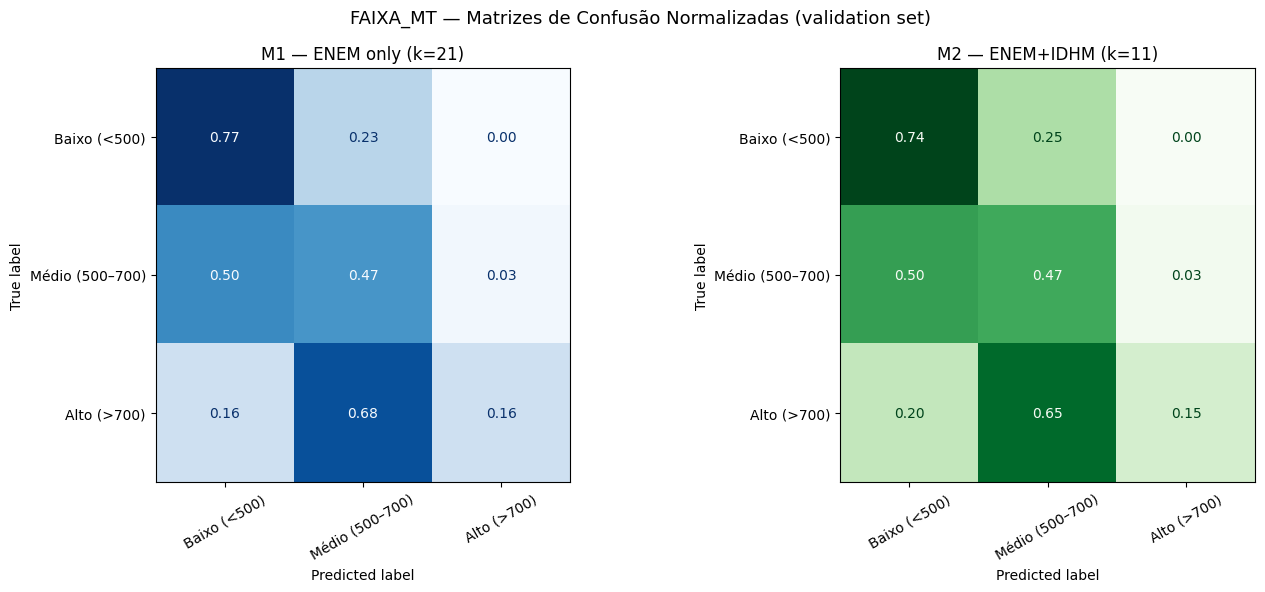

Figura salva: fig_cm_comparativo.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_m1, cm_m2],
    [f'M1 — ENEM only (k={best_k_m1})', f'M2 — ENEM+IDHM (k={best_k_m2})'],
    ['Blues', 'Greens']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER)
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('FAIXA_MT — Matrizes de Confusão Normalizadas (validation set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_cm_comparativo.png', dpi=150)
plt.show()
print('Figura salva: fig_cm_comparativo.png')

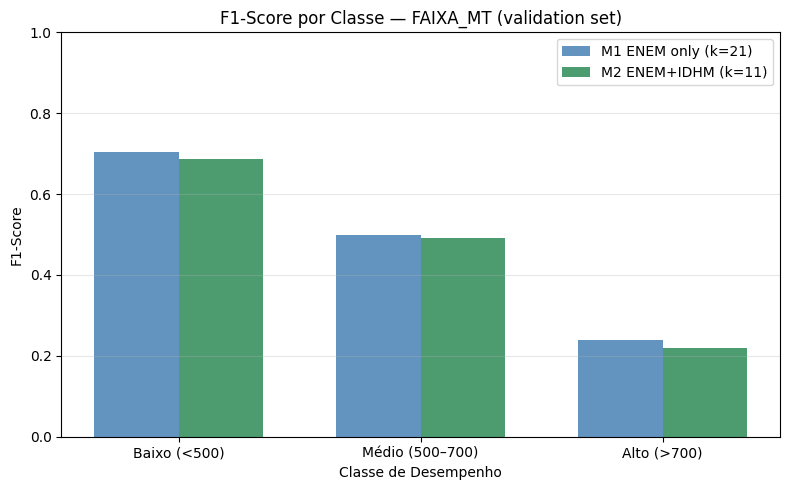

Figura salva: fig_f1_por_classe.png


In [16]:
f1_m1_by_class = f1_score(y_val, yp_m1, average=None, labels=[0, 1, 2])
f1_m2_by_class = f1_score(y_val, yp_m2, average=None, labels=[0, 1, 2])

x = np.arange(len(FAIXA_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1_m1_by_class, w, label=f'M1 ENEM only (k={best_k_m1})', color='steelblue', alpha=0.85)
ax.bar(x + w/2, f1_m2_by_class, w, label=f'M2 ENEM+IDHM (k={best_k_m2})', color='seagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_xlabel('Classe de Desempenho')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('F1-Score por Classe — FAIXA_MT (validation set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_f1_por_classe.png', dpi=150)
plt.show()
print('Figura salva: fig_f1_por_classe.png')

## Seção 9 — Segundo Target: FAIXA_REDACAO

Repetição do pipeline para o target `FAIXA_REDACAO` (nota da Redação).
Faixas com valores ausentes (candidatos sem nota de redação) são removidas da amostra.

In [17]:
mask_red = df['y_red'].notna()
df_red   = df[mask_red]
print(f'Registros com FAIXA_REDACAO válida: {len(df_red):,} ({len(df_red)/len(df)*100:.1f}%)')

X_red_all = df_red[ALL_FEATS].values.astype('float32')
y_red_all = df_red['y_red'].values.astype('int8')

Xr_tmp, Xr_test, yr_tmp, yr_test = train_test_split(
    X_red_all, y_red_all, test_size=0.20, stratify=y_red_all, random_state=RANDOM_STATE
)
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    Xr_tmp, yr_tmp, test_size=0.25, stratify=yr_tmp, random_state=RANDOM_STATE
)

Xrtr_m1, Xrv_m1 = Xr_train[:, idx_m1], Xr_val[:, idx_m1]
Xrtr_m2, Xrv_m2 = Xr_train[:, idx_m2], Xr_val[:, idx_m2]

print(f'  Train: {len(yr_train):,} | Val: {len(yr_val):,} | Test: {len(yr_test):,} [SELADO]')

Registros com FAIXA_REDACAO válida: 138,610 (99.7%)
  Train: 83,166 | Val: 27,722 | Test: 27,722 [SELADO]


In [18]:
print('=== FAIXA_REDACAO — Modelo 1: KNN (ENEM only) ===')
k_red_m1, best_red_m1 = select_best_params(Xrtr_m1, Xrv_m1, yr_train, yr_val)

bk_rm1, bmet_rm1 = best_red_m1
pipe_red_m1 = make_knn_pipeline(bk_rm1, bmet_rm1)
pipe_red_m1.fit(Xrtr_m1, yr_train)
yp_red_m1 = pipe_red_m1.predict(Xrv_m1)

=== FAIXA_REDACAO — Modelo 1: KNN (ENEM only) ===
   k        metric   Accuracy   Macro F1  Weighted F1
-------------------------------------------------------
   5     euclidean     0.4763     0.4654       0.4742
   7     euclidean     0.4843     0.4739       0.4826
   9     euclidean     0.4915     0.4803       0.4894
  11     euclidean     0.4938     0.4821       0.4914
  21     euclidean     0.5079     0.4939       0.5044
   5     manhattan     0.4771     0.4661       0.4750
   7     manhattan     0.4848     0.4744       0.4831
   9     manhattan     0.4918     0.4808       0.4898
  11     manhattan     0.4969     0.4847       0.4943
  21     manhattan     0.5105     0.4956       0.5067

  Melhor combo (Macro F1): k=21, metric=manhattan  →  F1=0.4956


In [19]:
print('=== FAIXA_REDACAO — Modelo 2: KNN (ENEM + IDHM) ===')
k_red_m2, best_red_m2 = select_best_params(Xrtr_m2, Xrv_m2, yr_train, yr_val)

bk_rm2, bmet_rm2 = best_red_m2
pipe_red_m2 = make_knn_pipeline(bk_rm2, bmet_rm2)
pipe_red_m2.fit(Xrtr_m2, yr_train)
yp_red_m2 = pipe_red_m2.predict(Xrv_m2)

=== FAIXA_REDACAO — Modelo 2: KNN (ENEM + IDHM) ===
   k        metric   Accuracy   Macro F1  Weighted F1
-------------------------------------------------------
   5     euclidean     0.4805     0.4686       0.4782
   7     euclidean     0.4903     0.4778       0.4879
   9     euclidean     0.4941     0.4826       0.4919
  11     euclidean     0.5016     0.4889       0.4988
  21     euclidean     0.5122     0.4956       0.5077
   5     manhattan     0.4817     0.4687       0.4790
   7     manhattan     0.4920     0.4781       0.4892
   9     manhattan     0.4973     0.4839       0.4945
  11     manhattan     0.5032     0.4888       0.4999
  21     manhattan     0.5106     0.4938       0.5062

  Melhor combo (Macro F1): k=21, metric=euclidean  →  F1=0.4956


In [20]:
dummy_red = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_red.fit(Xrtr_m1, yr_train)
yp_dummy_red = dummy_red.predict(Xrv_m1)

rows_red = [
    ('Baseline (majority)', '—', '—',
     accuracy_score(yr_val, yp_dummy_red),
     f1_score(yr_val, yp_dummy_red, average='macro'),
     f1_score(yr_val, yp_dummy_red, average='weighted')),
    ('KNN — ENEM only', bk_rm1, bmet_rm1,
     accuracy_score(yr_val, yp_red_m1),
     f1_score(yr_val, yp_red_m1, average='macro'),
     f1_score(yr_val, yp_red_m1, average='weighted')),
    ('KNN — ENEM + IDHM', bk_rm2, bmet_rm2,
     accuracy_score(yr_val, yp_red_m2),
     f1_score(yr_val, yp_red_m2, average='macro'),
     f1_score(yr_val, yp_red_m2, average='weighted')),
]

df_results_red = pd.DataFrame(rows_red,
    columns=['Modelo', 'k', 'Métrica dist.', 'Accuracy', 'Macro F1', 'Weighted F1'])

print('=== Tabela Comparativa — FAIXA_REDACAO (validation set) ===')
print(df_results_red.to_string(index=False))

=== Tabela Comparativa — FAIXA_REDACAO (validation set) ===
             Modelo  k Métrica dist.  Accuracy  Macro F1  Weighted F1
Baseline (majority)  —             —  0.450256  0.206978     0.279579
    KNN — ENEM only 21     manhattan  0.510461  0.495624     0.506674
  KNN — ENEM + IDHM 21     euclidean  0.512156  0.495556     0.507735


## Seção 10 — Persistência dos Modelos

Modelos e conjuntos de teste são salvos para uso na entrega final (SVM + algoritmo genético).
Os conjuntos de teste permanecem selados para avaliação definitiva.

In [21]:
import pickle

artifacts = {
    # Modelos FAIXA_MT
    f'{MODELS_DIR}/knn_enem_only_faixa_mt.pkl':   pipe_m1,
    f'{MODELS_DIR}/knn_enem_idhm_faixa_mt.pkl':   pipe_m2,
    # Modelos FAIXA_REDACAO
    f'{MODELS_DIR}/knn_enem_only_faixa_red.pkl':  pipe_red_m1,
    f'{MODELS_DIR}/knn_enem_idhm_faixa_red.pkl':  pipe_red_m2,
}

for path, obj in artifacts.items():
    joblib.dump(obj, path)
    print(f'Salvo: {path}')

# Conjuntos de teste selados (para entrega final)
test_sets = {
    'X_test_m1':     Xte_m1,
    'X_test_m2':     Xte_m2,
    'X_test_m3':     Xte_m3,
    'X_test_m4':     Xte_m4,
    'y_test_mt':     y_test,
    'X_test_red_m1': Xr_test[:, idx_m1],
    'X_test_red_m2': Xr_test[:, idx_m2],
    'y_test_red':    yr_test,
    'feat_names_m1': FEATS_M1,
    'feat_names_m2': FEATS_M2,
    'feat_names_m3': FEATS_M3,
    'feat_names_m4': FEATS_M4,
    'faixa_3_map':   FAIXA_3_MAP,
    'faixa_map_inv': FAIXA_MAP_INV,
    'faixa_order':   FAIXA_ORDER,
}
joblib.dump(test_sets, f'{MODELS_DIR}/test_sets_selados.pkl')
print(f'\nTest sets selados: {MODELS_DIR}/test_sets_selados.pkl')


Salvo: ../data/models/knn_enem_only_faixa_mt.pkl
Salvo: ../data/models/knn_enem_idhm_faixa_mt.pkl
Salvo: ../data/models/knn_enem_only_faixa_red.pkl
Salvo: ../data/models/knn_enem_idhm_faixa_red.pkl

Test sets selados: ../data/models/test_sets_selados.pkl


In [22]:
# Tabela consolidada para copiar no artigo
print('=' * 70)
print('RESUMO FINAL — Resultados Parciais (validation set)')
print('=' * 70)
print('\n[Target: FAIXA_MT]')
print(df_results.to_string(index=False))
print('\n[Target: FAIXA_REDACAO]')
print(df_results_red.to_string(index=False))
print('\n* Métricas no test set serão divulgadas apenas na entrega final.')

RESUMO FINAL — Resultados Parciais (validation set)

[Target: FAIXA_MT]
             Modelo  k Métrica dist.  Accuracy  Macro F1  Weighted F1
Baseline (majority)  —             —  0.523053  0.228949     0.359257
    KNN — ENEM only 21     manhattan  0.604186  0.481009     0.588399
  KNN — ENEM + IDHM 11     euclidean  0.589333  0.466152     0.574934

[Target: FAIXA_REDACAO]
             Modelo  k Métrica dist.  Accuracy  Macro F1  Weighted F1
Baseline (majority)  —             —  0.450256  0.206978     0.279579
    KNN — ENEM only 21     manhattan  0.510461  0.495624     0.506674
  KNN — ENEM + IDHM 21     euclidean  0.512156  0.495556     0.507735

* Métricas no test set serão divulgadas apenas na entrega final.


## Seção 10 — Discussão Preliminar e Limitações

### Interpretação dos Resultados Parciais

**Pergunta central**: os indicadores socioeconômicos estaduais (IDHM) melhoram a predição
da faixa de desempenho no ENEM além do que as variáveis individuais já explicam?

**Sobre a Hipótese H3**: `Δ Macro F1 (M2 − M1) > 0` indica que o contexto regional agrega
informação preditiva mesmo após controlar por renda familiar, escolaridade dos pais e tipo de escola.

**Sobre classes**: 3 faixas (Baixo/Médio/Alto) reduzem a fragmentação e tornam as métricas
mais interpretáveis do que as 6 faixas originais. A faixa Alto (~7% dos candidatos) ainda é
sub-representada, o que limita o recall nessa classe.

---

### Limitações

1. **Amostragem (500k/14.2M)**: KNN não escala ao volume completo. Amostra preserva proporções
   de classe mas pode sub-representar padrões locais de municípios pequenos.
2. **IDHM estadual**: todos os candidatos do mesmo estado/ano recebem o mesmo valor — granularidade
   limitada. Dados municipais mudariam substancialmente o Modelo 2.
3. **KNN como modelo transitório**: resultados definitivos virão com SVM + algoritmo genético
   na entrega final, avaliados no test set selado.

---

### Próximos Passos (Entrega Final)

- [ ] Modelo 3: KNN com IDHM desagregado por raça e gênero
- [ ] SVM com algoritmo genético para seleção de hiperparâmetros
- [ ] Avaliação final no **test set selado** (`data/models/test_sets_selados.pkl`)
- [ ] Análise de ablação: contribuição de cada grupo de features